# 三、生成网络

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# PyTorch 深度学习框架
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

# 自动选择设备（有GPU用GPU，无GPU用CPU）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"当前运行设备: {device}")

当前运行设备: cpu


## 1.生成对抗网络
下列代码搭建基于全连接层的基础 GAN，用于 MNIST 手写数字图像生成。模型包含生成器与判别器两个对抗网络：生成器将随机噪声映射为 28×28 手写数字图像，判别器负责辨别图像真伪。采用交替训练策略、二元交叉熵损失实现对抗学习；训练完成后可视化损失曲线与生成样本，验证 GAN 图像生成能力。

Epoch 1/5 | D损失: 1.1906 | G损失: 0.9737
Epoch 2/5 | D损失: 1.0783 | G损失: 1.2090
Epoch 3/5 | D损失: 1.0223 | G损失: 1.3276
Epoch 4/5 | D损失: 1.0001 | G损失: 1.3950
Epoch 5/5 | D损失: 1.0812 | G损失: 1.2313


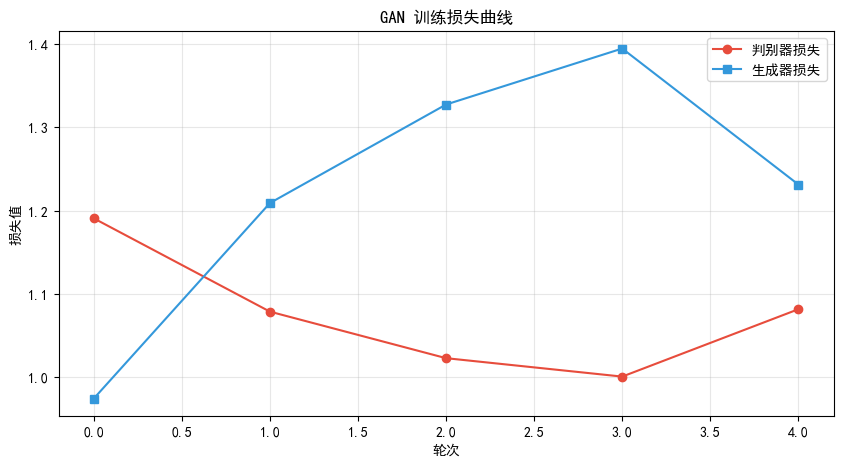

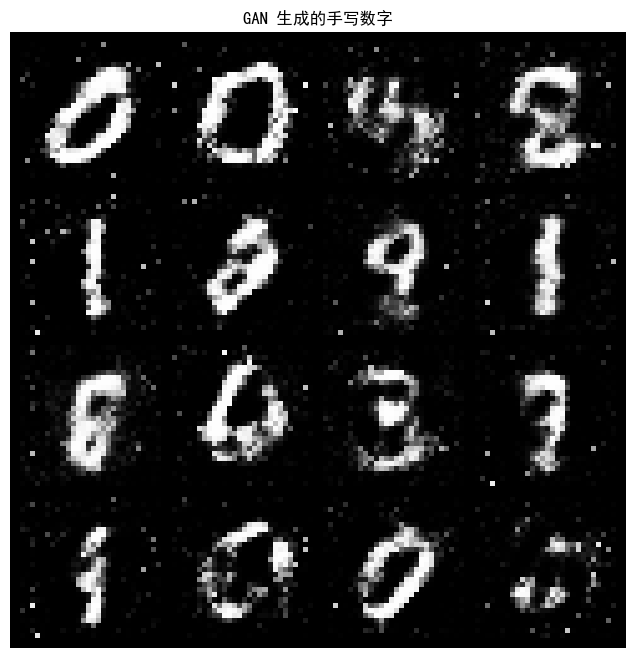

In [6]:
# 1.数据集加载
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   
])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# 2. 模型定义 
latent_dim = 100  # 随机噪声维度
# 生成器：噪声 → 28×28 图片
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 784),
            nn.Tanh()  # 输出归一化到 [-1, 1]
        )
    
    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)

# 判别器：图片 → 真假概率
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()  # 输出 0~1 概率
        )
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

# 3.初始化
G = Generator().to(device)
D = Discriminator().to(device)
criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

# 4.交替训练判别器和生成器
epochs = 5
d_loss_history = []
g_loss_history = []

for epoch in range(epochs):
    d_total_loss = 0
    g_total_loss = 0
    
    for real_imgs, _ in train_loader:
        batch_size = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)
        
        # ----- 训练判别器 -----
        opt_D.zero_grad()
        # 真实样本损失
        real_out = D(real_imgs)
        d_loss_real = criterion(real_out, real_labels)
        # 假样本损失
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_imgs = G(z)
        fake_out = D(fake_imgs.detach())  # detach：不更新生成器
        d_loss_fake = criterion(fake_out, fake_labels)
        
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        opt_D.step()
        
        # ----- 训练生成器 -----
        opt_G.zero_grad()
        fake_out = D(fake_imgs)
        g_loss = criterion(fake_out, real_labels)  # 欺骗判别器
        g_loss.backward()
        opt_G.step()
        
        d_total_loss += d_loss.item()
        g_total_loss += g_loss.item()
    
    avg_d = d_total_loss / len(train_loader)
    avg_g = g_total_loss / len(train_loader)
    d_loss_history.append(avg_d)
    g_loss_history.append(avg_g)
    print(f"Epoch {epoch+1}/{epochs} | D损失: {avg_d:.4f} | G损失: {avg_g:.4f}")

# 5.可视化结果 
# 损失曲线
plt.figure(figsize=(10, 5))
plt.plot(d_loss_history, 'o-', label='判别器损失', color='#e74c3c')
plt.plot(g_loss_history, 's-', label='生成器损失', color='#3498db')
plt.xlabel('轮次')
plt.ylabel('损失值')
plt.title('GAN 训练损失曲线')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
G.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    generated = G(z).cpu()

plt.figure(figsize=(8, 8))
grid = make_grid(generated, nrow=4, normalize=True)
plt.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
plt.title('GAN 生成的手写数字')
plt.axis('off')
plt.show()

分析：
* 模型成功学习到 MNIST 手写数字的基础轮廓，能够生成形态可辨认的数字，证明该全连接 GAN 具备基础图像生成能力。
* 生成图片存在明显噪点，边缘模糊，部分数字轮廓失真。
* 训练迭代轮次较少，模型未充分收敛；
* 原始 GAN 本身存在训练不稳定、易产生噪声伪影的缺陷。

## 2.变分自编码器
本模型搭建变分自编码器（VAE），在 MNIST 手写数字数据集开展图像生成实验。编码器将图像映射至二维分布，借助重参数化技巧采样潜在变量，解码器由潜在变量重构图像。损失函数结合二元交叉熵重构损失与 KL 散度正则项，交替优化编码器与解码器。训练完成后，实现随机采样生成手写数字、可视化二维潜在空间分布，同时绘制训练损失曲线，验证 VAE 图像生成与隐空间特征学习能力。

Epoch 1/10 | 平均损失: 180.3356
Epoch 2/10 | 平均损失: 160.0902
Epoch 3/10 | 平均损失: 155.7573
Epoch 4/10 | 平均损失: 152.7321
Epoch 5/10 | 平均损失: 150.4808
Epoch 6/10 | 平均损失: 148.7390
Epoch 7/10 | 平均损失: 147.2662
Epoch 8/10 | 平均损失: 146.7370
Epoch 9/10 | 平均损失: 145.8130
Epoch 10/10 | 平均损失: 144.9197


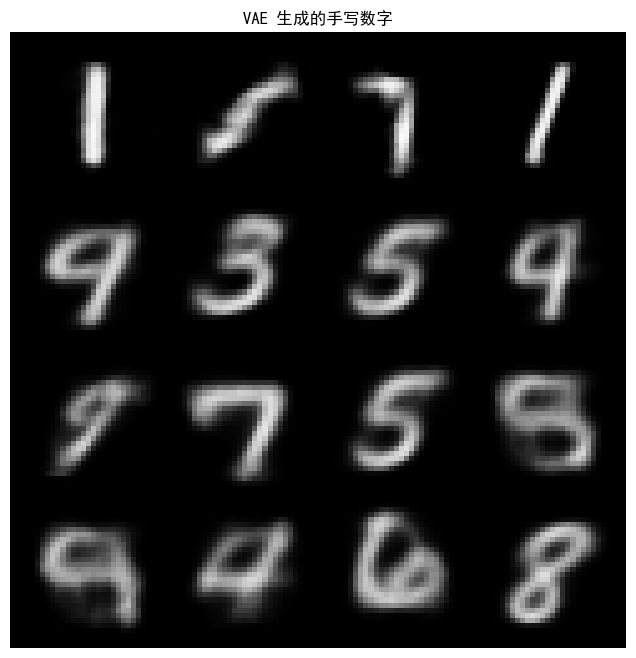

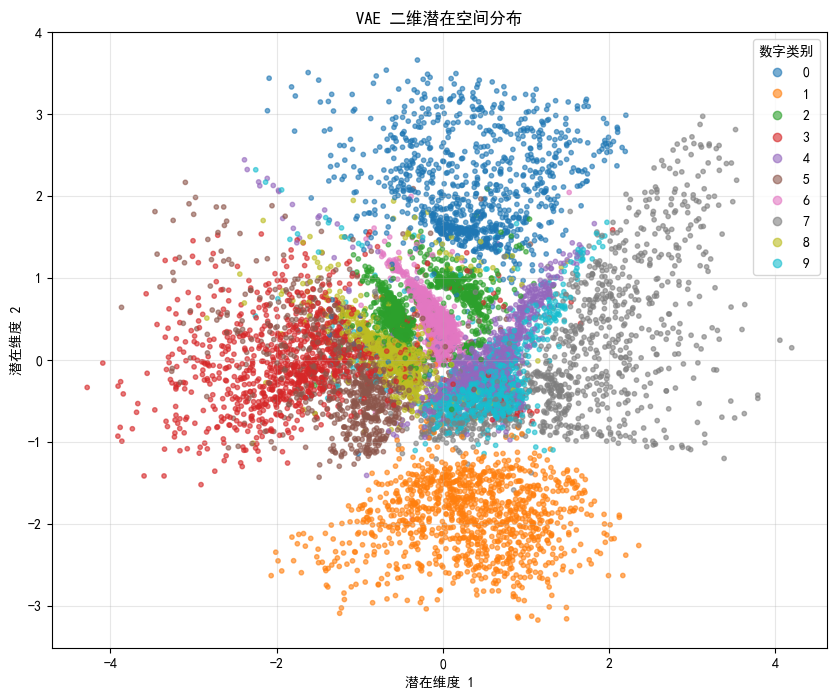

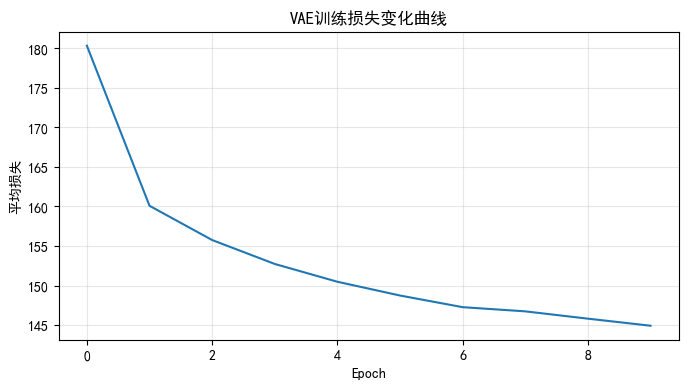

In [8]:
# VAE专用数据集
transform = transforms.Compose([
    transforms.ToTensor()   # 只保留ToTensor，像素锁定 [0,1]
])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 1. VAE 模型定义
class VAE(nn.Module):
    def __init__(self, input_dim=784, latent_dim=2):
        super().__init__()
        # 编码器：输出均值 mu 和对数方差 logvar
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )
        self.mu_layer = nn.Linear(128, latent_dim)
        self.logvar_layer = nn.Linear(128, latent_dim)
        
        # 解码器：从潜在向量生成图片
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid()  # 输出 [0,1]
        )
    
    def encode(self, x):
        h = self.encoder(x.view(x.size(0), -1))
        return self.mu_layer(h), self.logvar_layer(h)
    
    def reparameterize(self, mu, logvar):
        """重参数化技巧：让采样可导"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

#  2. 损失函数与训练 
vae = VAE(latent_dim=2).to(device)
optimizer = optim.Adam(vae.parameters(), lr=0.001)

def vae_loss(recon_x, x, mu, logvar):
    # 重构损失：二元交叉熵
    recon_loss = nn.functional.binary_cross_entropy(recon_x.view(-1,784), x.view(-1,784), reduction='sum')
    # KL散度：正则化，让潜在分布趋近标准正态分布
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss

# 3.训练
epochs = 10
loss_history = []
vae.train()
for epoch in range(epochs):
    total_loss = 0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = vae(imgs)
        loss = vae_loss(recon_batch, imgs, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader.dataset)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} | 平均损失: {avg_loss:.4f}")

# 4.可视化 
# 生成样本
vae.eval()
with torch.no_grad():
    z = torch.randn(16, 2).to(device)
    generated = vae.decode(z).cpu()

plt.figure(figsize=(8, 8))
grid = make_grid(generated, nrow=4)
plt.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
plt.title('VAE 生成的手写数字')
plt.axis('off')
plt.show()

# 二维潜在空间可视化
latents = []
labels = []
with torch.no_grad():
    for imgs, targets in test_loader:
        imgs = imgs.to(device)
        mu, _ = vae.encode(imgs)
        latents.append(mu.cpu().numpy())
        labels.append(targets.numpy())

latents = np.concatenate(latents)
labels = np.concatenate(labels)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(latents[:, 0], latents[:, 1], c=labels, cmap='tab10', alpha=0.6, s=10)
plt.xlabel('潜在维度 1')
plt.ylabel('潜在维度 2')
plt.title('VAE 二维潜在空间分布')
plt.legend(*scatter.legend_elements(), title='数字类别')
plt.grid(alpha=0.3)
plt.show()

# 绘制损失曲线
plt.figure(figsize=(8,4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("平均损失")
plt.title("VAE训练损失变化曲线")
plt.grid(alpha=0.3)
plt.show()

分析：
* 训练损失持续下降，前期快速收敛，后期下降速度放缓；训练 10 轮后仍有下降空间，模型未完全收敛。
* 可以生成能够识别的手写数字，证明模型具备图像生成能力；生成图像较为模糊，源于 VAE 本身优化目标特点，同时潜在维度仅为 2 维、训练轮次不足，表征能力有限。
* 相同数字类别在隐空间聚集，不同类别形成相对独立簇，编码器学到有效特征；类别之间存在连续过渡区域，体现 VAE 隐空间连续性；KL 正则项发挥作用，整体分布趋近正态分布。

## 3.扩散模型
代码实现了扩散模型前向扩散过程仿真。设置线性 beta 噪声调度，推导累积乘积系数，利用扩散闭式公式构建前向加噪函数。选取单张手写数字图片，在多个关键时间步计算对应的加噪图像并可视化，直观展示原始图像不断叠加高斯噪声、逐步退化至纯噪声的全过程。

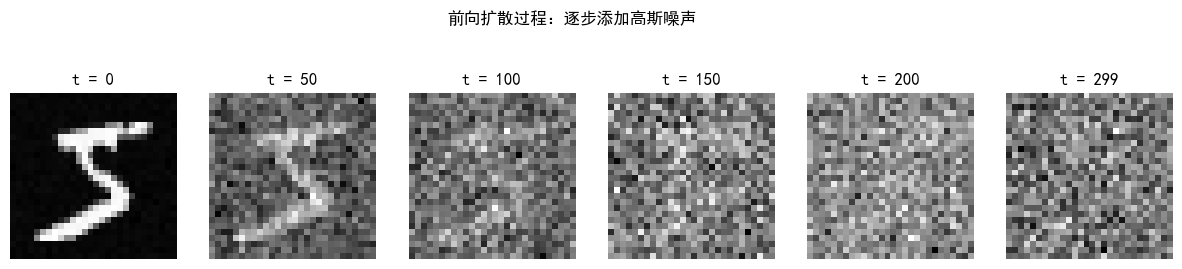

In [9]:
# 1. 前向扩散过程可视化 
timesteps = 300
beta_start = 1e-4
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, timesteps)
alphas = 1 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)  # 累积乘积

def forward_diffusion(x_0, t):
    """给定原始图片 x_0，返回 t 步后的加噪图片和对应噪声"""
    noise = torch.randn_like(x_0)
    sqrt_alpha = torch.sqrt(alphas_cumprod[t]).view(-1, 1, 1, 1)
    sqrt_one_minus_alpha = torch.sqrt(1 - alphas_cumprod[t]).view(-1, 1, 1, 1)
    x_t = sqrt_alpha * x_0 + sqrt_one_minus_alpha * noise
    return x_t, noise

# 取一张真实图片，观察逐步加噪过程
sample_img = train_dataset[0][0].unsqueeze(0)
show_steps = [0, 50, 100, 150, 200, 299]

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i, t in enumerate(show_steps):
    x_t, _ = forward_diffusion(sample_img, torch.tensor([t]))
    axes[i].imshow(x_t[0, 0].numpy(), cmap='gray')
    axes[i].set_title(f't = {t}')
    axes[i].axis('off')
plt.suptitle('前向扩散过程：逐步添加高斯噪声', y=1.05)
plt.show()


分析：
* t=0：图片为原始清晰手写数字，无噪声。
* t 逐步增大（50→100→150→200→299）：持续向图像叠加高斯噪声，数字轮廓不断模糊，有效信息逐步被噪声覆盖。
* t 接近最大步数 299：图像几乎完全变成纯随机噪声，原始图像信息基本消失，符合扩散模型前向扩散理论：足够多步加噪后图像趋近标准正态分布。